# Batch single-FOV FLIM fitting
Fits every `.ptu` in a folder with a 3-exponential reconvolution model,  
exports one row per file to a CSV.

**Settings** — edit the config cell below, then `Run All`.

| Parameter | Value |
|-----------|-------|
| Exponentials | 3 |
| τ range | 0.145 – 45 ns |
| IRF | Machine IRF (peak-aligned to decay) |
| Optimizer | Differential evolution → LM polish |
| Output | `<PTU_FOLDER>/batch_fit_results.csv` |


In [25]:
from pathlib import Path

# ── Edit these ────────────────────────────────────────────────────────────
PTU_FOLDER       = Path("/Volumes/Lexar/Layla/260309LMCR196TCAFADO40x.sptw/")          # folder containing .ptu files
OUTPUT_CSV       = PTU_FOLDER / "batch_fit_results.csv"

# Fitting parameters
N_EXP            = 3
TAU_MIN_NS       = 0.145                  # ns  (matches 1.5 bins @ 97 ps)
TAU_MAX_NS       = 45.0                   # ns

# Machine IRF — leave None to use FLIMKit default
MACHINE_IRF_PATH = None                   # e.g. Path("machine_irf.npy")

# DE optimiser settings (reduce for speed, increase for accuracy)
DE_POPSIZE       = 15
DE_MAXITER       = 1000
WORKERS          = -1                     # -1 = use all cores

# Skip files with fewer total photons than this
MIN_PHOTONS      = 1_000


In [26]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from flimkit.PTU.reader      import PTUFile
from flimkit.FLIM.fitters    import fit_summed
from flimkit.configs         import (
    MACHINE_IRF_DEFAULT_PATH,
    MACHINE_IRF_FIT_BG, MACHINE_IRF_FIT_SIGMA, MACHINE_IRF_FIT_TAIL,
)

# Resolve IRF path
_irf_path = Path(MACHINE_IRF_PATH) if MACHINE_IRF_PATH else Path(MACHINE_IRF_DEFAULT_PATH)
if not _irf_path.exists():
    raise FileNotFoundError(f"Machine IRF not found: {_irf_path}")

_machine_irf_raw = np.load(str(_irf_path)).ravel().astype(float)
_machine_irf_raw = np.maximum(_machine_irf_raw, 0.0)
_machine_irf_raw /= _machine_irf_raw.sum()
PI_MACHINE = int(np.argmax(_machine_irf_raw))

print(f"Machine IRF: {_irf_path.name}  |  {len(_machine_irf_raw)} bins  |  peak bin {PI_MACHINE}")
print(f"FIT_BG={MACHINE_IRF_FIT_BG}  FIT_SIGMA={MACHINE_IRF_FIT_SIGMA}  HAS_TAIL={MACHINE_IRF_FIT_TAIL}")
print(f"n_exp={N_EXP}  τ=[{TAU_MIN_NS}, {TAU_MAX_NS}] ns")

def get_irf(peak_bin: int, n_bins: int) -> np.ndarray:
    irf = _machine_irf_raw.copy()
    if irf.size > n_bins:
        irf = irf[:n_bins]
    elif irf.size < n_bins:
        irf = np.pad(irf, (0, n_bins - irf.size))
    shift = peak_bin - PI_MACHINE
    if shift:
        irf = np.roll(irf, shift)
    s = irf.sum()
    return irf / s if s > 0 else irf

print("\nImports OK ✓")


Machine IRF: machine_irf_default.npy  |  526 bins  |  peak bin 29
FIT_BG=True  FIT_SIGMA=False  HAS_TAIL=False
n_exp=3  τ=[0.145, 45.0] ns

Imports OK ✓


In [27]:
ptu_files = sorted(PTU_FOLDER.glob("*.ptu"))
print(f"Found {len(ptu_files)} .ptu files in {PTU_FOLDER}")
for p in ptu_files:
    print(f"  {p.name}")


Found 32 .ptu files in /Volumes/Lexar/Layla/260309LMCR196TCAFADO40x.sptw
  AB680_1.ptu
  AB680_2.ptu
  AB680_Ado_1.ptu
  AB680_Ado_2.ptu
  Ado_1.ptu
  Ado_2.ptu
  Ctrl_1.ptu
  Ctrl_2.ptu
  Daratumab_1.ptu
  Daratumab_2.ptu
  Daratumab_Ado_1.ptu
  Daratumab_Ado_2.ptu
  Etr_Pom1_PSB_1.ptu
  Etr_Pom1_PSB_2.ptu
  Etr_Pom1_PSB_Ado_1.ptu
  Etr_Pom1_PSB_Ado_2.ptu
  Etrumadenant_1.ptu
  Etrumadenant_2.ptu
  Etrumadenant_Ado_1.ptu
  Etrumadenant_Ado_2.ptu
  Imaradenant_1.ptu
  Imaradenant_2.ptu
  Imaradenant_Ado_1.ptu
  Imaradenant_Ado_2.ptu
  PSB12379_1.ptu
  PSB12379_2.ptu
  PSB12379_Ado_1.ptu
  PSB12379_Ado_2.ptu
  Pom1_1.ptu
  Pom1_2.ptu
  Pom1_Ado_1.ptu
  Pom1_Ado_2.ptu


In [28]:
from tqdm.notebook import tqdm

records = []
errors  = []

for ptu_path in tqdm(ptu_files, desc="Fitting"):
    row = {"file": ptu_path.name}
    try:
        ptu    = PTUFile(str(ptu_path), verbose=False)
        decay  = ptu.summed_decay()
        n_bins = ptu.n_bins
        tcspc  = ptu.tcspc_res           # seconds
        n_ph   = int(decay.sum())

        row["n_photons"]  = n_ph
        row["n_bins"]     = n_bins
        row["tcspc_ps"]   = round(tcspc * 1e12, 4)
        row["peak_bin"]   = int(np.argmax(decay))

        if n_ph < MIN_PHOTONS:
            row["status"] = f"SKIPPED (<{MIN_PHOTONS} photons)"
            records.append(row)
            continue

        irf = get_irf(row["peak_bin"], n_bins)

        popt, s = fit_summed(
            decay, tcspc, n_bins, irf,
            has_tail  = MACHINE_IRF_FIT_TAIL,
            fit_bg    = MACHINE_IRF_FIT_BG,
            fit_sigma = MACHINE_IRF_FIT_SIGMA,
            n_exp         = N_EXP,
            tau_min_ns    = TAU_MIN_NS,
            tau_max_ns    = TAU_MAX_NS,
            optimizer     = "de",
            de_popsize    = DE_POPSIZE,
            de_maxiter    = DE_MAXITER,
            workers       = WORKERS,
            polish        = True,
        )

        # Lifetimes and amplitudes (sorted τ₁ > τ₂ > τ₃ by fit_summed)
        taus  = s["taus_ns"]        # ns, descending
        amps  = s["amps"]
        fracs = s["fractions"]

        for k in range(N_EXP):
            row[f"tau{k+1}_ns"]    = round(float(taus[k]),  5)
            row[f"amp{k+1}"]       = round(float(amps[k]),  4)
            row[f"frac{k+1}"]      = round(float(fracs[k]), 5)

        row["tau_mean_amp_ns"]   = round(s["tau_mean_amp_ns"],   5)
        row["tau_mean_int_ns"]   = round(s["tau_mean_int_ns"],   5)
        row["bg_fit"]            = round(float(s["bg_fit"]),     6)
        row["chi2_reduced"]      = round(s["reduced_chi2"],      5)
        row["chi2_reduced_tail"] = round(s["reduced_chi2_tail"], 5)
        row["chi2_full"]         = round(s["chi2"],              4)
        row["dof"]               = int(s["dof"])
        row["p_val"]             = round(s["p_val"],             6)
        row["irf_shift_bins"]    = round(float(s["irf_shift_bins"]), 4)
        row["irf_fwhm_eff_ns"]   = round(float(s["irf_fwhm_eff_ns"]), 4)
        row["fit_window_ns_lo"]  = round(s["fit_window_ns"][0], 4)
        row["fit_window_ns_hi"]  = round(s["fit_window_ns"][1], 4)
        row["optimizer_msg"]     = str(s["optimizer_msg"])[:80]
        row["status"]            = "OK"

    except Exception as e:
        row["status"] = f"ERROR: {e}"
        errors.append(ptu_path.name)
        import traceback; traceback.print_exc()

    records.append(row)

print(f"\n{sum(1 for r in records if r['status']=='OK')}/{len(ptu_files)} files fitted successfully")
if errors:
    print(f"Errors: {errors}")


Fitting:   0%|          | 0/32 [00:00<?, ?it/s]

  Next-period artefact at bin 485 (47.03 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 549.500 cts/bin, upper bound = 1099.000 (free param)
  σ broadening: fixed at 0
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=15, maxiter=1000, workers=-1
  Running final LM polish...
  Next-period artefact at bin 485 (47.03 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 496.500 cts/bin, upper bound = 993.000 (free param)
  σ broadening: fixed at 0
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=15, maxiter=1000, workers=-1
  Running final LM polish...
  Next-period artefact at bin 485 (47.03 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 585.500 cts/bin, upper bound = 1171.000 (free param)
  σ broadening: fixed at 0
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=15, maxiter=1000, workers=-1
  Running final 

In [29]:
df = pd.DataFrame(records)

# Reorder columns logically
front_cols = ["file", "status", "n_photons", "tcspc_ps", "n_bins", "peak_bin"]
tau_cols   = []
for k in range(N_EXP):
    tau_cols += [f"tau{k+1}_ns", f"amp{k+1}", f"frac{k+1}"]
mean_cols  = ["tau_mean_amp_ns", "tau_mean_int_ns"]
fit_cols   = ["bg_fit", "chi2_reduced", "chi2_reduced_tail", "chi2_full",
              "dof", "p_val", "irf_shift_bins", "irf_fwhm_eff_ns",
              "fit_window_ns_lo", "fit_window_ns_hi", "optimizer_msg"]

ordered = [c for c in front_cols + tau_cols + mean_cols + fit_cols if c in df.columns]
remaining = [c for c in df.columns if c not in ordered]
df = df[ordered + remaining]

df.to_csv(OUTPUT_CSV, index=False)
print(f"CSV saved → {OUTPUT_CSV}")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
df[df.status == "OK"].head(10)


CSV saved → /Volumes/Lexar/Layla/260309LMCR196TCAFADO40x.sptw/batch_fit_results.csv
Shape: 32 rows × 28 columns



,file,status,n_photons,tcspc_ps,n_bins,peak_bin,tau1_ns,amp1,frac1,tau2_ns,...,chi2_reduced,chi2_reduced_tail,chi2_full,dof,p_val,irf_shift_bins,irf_fwhm_eff_ns,fit_window_ns_lo,fit_window_ns_hi,optimizer_msg
0,AB680_1.ptu,OK,3518656,96.9697,529,29,6.10602,17702.5433,0.07324,1.98750,...,8.76410,1.48736,3987.6638,455,0.0,-1.1562,0.097,0.097,44.9939,"DE success=True, fun=4.0741e+03; polished cost..."
1,AB680_2.ptu,OK,3996390,96.9697,530,29,6.07703,21091.9594,0.07557,1.96399,...,10.22635,1.62941,4652.9907,455,0.0,-1.1529,0.097,0.097,44.9939,"DE success=True, fun=4.7526e+03; polished cost..."
2,AB680_Ado_1.ptu,OK,3269800,96.9697,529,29,5.99621,17519.7751,0.08187,2.00224,...,8.40792,1.63215,3825.6030,455,0.0,-1.1520,0.097,0.097,44.9939,"DE success=True, fun=3.9012e+03; polished cost..."
3,AB680_Ado_2.ptu,OK,3074624,96.9697,531,29,6.10528,15684.7786,0.07839,2.02996,...,7.95422,1.48484,3619.1683,455,0.0,-1.1474,0.097,0.097,44.9939,"DE success=True, fun=3.6833e+03; polished cost..."
4,Ado_1.ptu,OK,2124579,96.9697,530,29,6.04459,12124.6713,0.07587,1.92647,...,7.27935,2.10564,3312.1051,455,0.0,-0.8679,0.097,0.097,44.9939,"DE success=True, fun=4.1609e+03; polished cost..."
5,Ado_2.ptu,OK,5452979,96.9697,529,29,6.55973,24811.0337,0.06525,2.22448,...,22.41055,2.03515,10196.7983,455,0.0,-1.0577,0.097,0.097,44.9939,"DE success=True, fun=1.0350e+04; polished cost..."
6,Ctrl_1.ptu,OK,5308600,96.9697,528,29,5.98112,30762.6815,0.07329,1.83655,...,10.82359,3.88959,4924.7352,455,0.0,-0.7297,0.097,0.097,44.9939,"DE success=True, fun=5.8492e+03; polished cost..."
7,Ctrl_2.ptu,OK,4643136,96.9697,532,29,5.89548,27526.9018,0.07520,1.81676,...,12.32948,3.28182,5609.9123,455,0.0,-0.7673,0.097,0.097,44.9939,"DE success=True, fun=6.9542e+03; polished cost..."
8,Daratumab_1.ptu,OK,3917985,96.9697,529,29,5.99178,20427.9365,0.07504,1.94999,...,10.26198,1.65572,4669.2012,455,0.0,-1.1500,0.097,0.097,44.9939,"DE success=True, fun=4.7770e+03; polished cost..."
9,Daratumab_2.ptu,OK,3592516,96.9697,531,29,5.98715,18668.3681,0.07542,1.98759,...,9.12345,1.46190,4151.1719,455,0.0,-1.1495,0.097,0.097,44.9939,"DE success=True, fun=4.2495e+03; polished cost..."


── Summary statistics ───────────────────────────────────────
       tau1_ns  tau2_ns  tau3_ns  tau_mean_amp_ns  chi2_reduced_tail
count  32.0000  32.0000  32.0000          32.0000            32.0000
mean    6.1498   2.0167   0.4027           1.2507             1.9115
std     0.1524   0.0845   0.0258           0.0337             0.5006
min     5.8955   1.8168   0.3274           1.1612             1.4619
25%     6.0284   1.9590   0.3975           1.2376             1.6315
50%     6.1312   2.0095   0.4036           1.2465             1.7846
75%     6.2628   2.0749   0.4155           1.2683             2.0006
max     6.5597   2.2245   0.4509           1.3275             3.8896


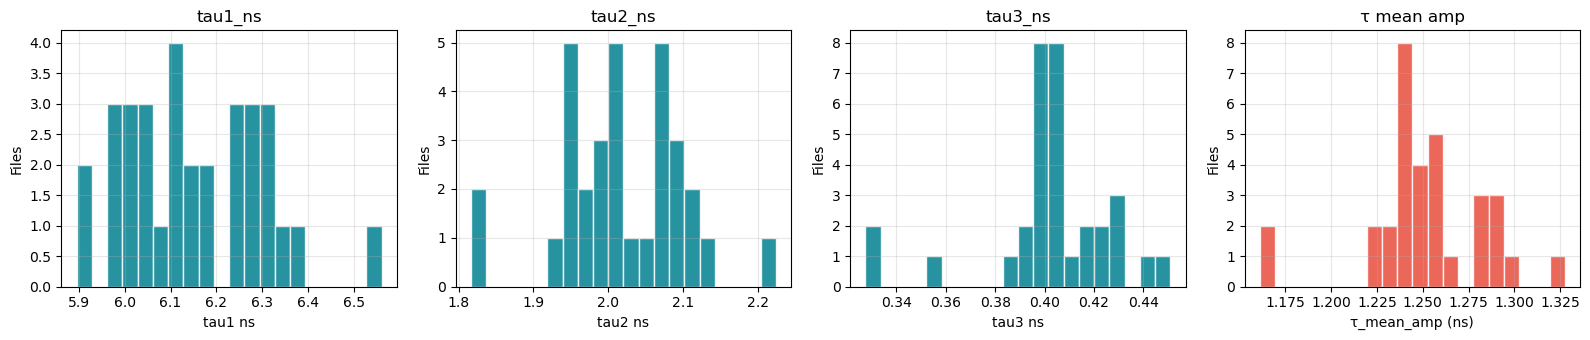


Plot saved → /Volumes/Lexar/Layla/260309LMCR196TCAFADO40x.sptw/batch_fit_tau_distributions.png


In [30]:
import matplotlib.pyplot as plt

ok = df[df.status == "OK"].copy()
if len(ok) == 0:
    print("No successful fits to plot.")
else:
    tau_keys = [f"tau{k+1}_ns" for k in range(N_EXP) if f"tau{k+1}_ns" in ok.columns]
    print("── Summary statistics ───────────────────────────────────────")
    cols_stat = tau_keys + ["tau_mean_amp_ns", "chi2_reduced_tail"]
    print(ok[cols_stat].describe().round(4).to_string())

    # Histogram of lifetimes
    fig, axes = plt.subplots(1, len(tau_keys) + 1, figsize=(4*(len(tau_keys)+1), 3.5))
    for ax, key in zip(axes, tau_keys):
        ax.hist(ok[key].dropna(), bins=20, color="#028090", edgecolor="white", alpha=0.85)
        ax.set_xlabel(key.replace("_", " "))
        ax.set_ylabel("Files")
        ax.set_title(key)
        ax.grid(True, alpha=0.3)

    axes[-1].hist(ok["tau_mean_amp_ns"].dropna(), bins=20,
                  color="#e74c3c", edgecolor="white", alpha=0.85)
    axes[-1].set_xlabel("τ_mean_amp (ns)")
    axes[-1].set_ylabel("Files")
    axes[-1].set_title("τ mean amp")
    axes[-1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(PTU_FOLDER / "batch_fit_tau_distributions.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nPlot saved → {PTU_FOLDER / 'batch_fit_tau_distributions.png'}")
